# Optional Supplement 01: Test a Visual Concept with TCAV

Testing with Concept Activation Vectors (`TCAV`) asks whether a model's output is sensitive to a human-defined concept. Here the concept is **closed-loop structure**, represented by MNIST digits `0`, `6`, and `9`. Comparison examples use digits `1`, `2`, `4`, `5`, and `7`. Digits `3` and `8` are excluded from concept training and used only as target classes.

> TCAV measures sensitivity in a model's internal representation. It does not prove that the model reasons with the concept, that the concept caused a prediction, or that the concept examples are perfectly isolated from other digit features.

## TCAV Process at a Glance

Use this diagram as a roadmap for the notebook. Phase 1 corresponds to Steps 3 and 4; Phase 2 corresponds to Steps 5 and 6.

![Two-phase TCAV workflow: learn repeated concept activation vectors by separating closed-loop and no-loop internal representations, then calculate directional sensitivities and aggregate class-level TCAV scores for digits 3 and 8.](./figures/vit_tcav.png)

*Figure. The notebook first learns five concept directions that separate has-loop from no-loop internal features. It then measures whether movement in each direction increases the binary class margin and aggregates the results into class-level TCAV scores.*

## Step 1: Setup and Checkpoint

Run Notebook 03 first. This notebook loads its checkpoint and uses only PyTorch, Torchvision, and Matplotlib.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

LAB_NAME = 'sub_01_vit_foundations'
lab_dir = Path.cwd().resolve()
if lab_dir.name != LAB_NAME:
    raise FileNotFoundError(f'Open this notebook from the {LAB_NAME} folder.')
checkpoint_path = lab_dir / 'outputs' / 'tiny_vit_mnist.pt'
if not checkpoint_path.exists():
    raise FileNotFoundError('Run 03_tiny_vit_digits_demo.ipynb first to create outputs/tiny_vit_mnist.pt.')
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else 'cpu')
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
SEED = int(checkpoint['seed'])
random.seed(SEED)
torch.manual_seed(SEED)
print('Analysis device:', device)

Analysis device: cpu


## Step 2: Load the Model and Expose Its Internal Features

The concept vector will live in the 64-value `[CLS]` representation produced by the encoder, just before final normalization and classification.

In [2]:
class PatchEmbedding(nn.Module):
    """Convert images into patch embeddings."""
    def __init__(self, image_size=28, patch_size=4, channels=1, embedding_size=64):
        """Create patch extraction and projection layers.

        Inputs: image size, patch size, channels, and embedding length.
        Output: None; layers are stored.
        """
        super().__init__()
        self.number_of_patches = (image_size // patch_size) ** 2
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        self.projection = nn.Linear(channels * patch_size * patch_size, embedding_size)

    def forward(self, images):
        """Project image patches into embeddings.

        Input: tensor shaped (batch, channels, height, width).
        Output: tensor shaped (batch, patches, embedding_size).
        """
        return self.projection(self.unfold(images).transpose(1, 2))

class TinyVisionTransformer(nn.Module):
    """Tiny ViT with access to its encoder CLS features."""
    def __init__(self, image_size=28, patch_size=4, embedding_size=64, heads=4, layers=2, classes=2):
        """Create the model.

        Inputs: architecture dimensions from the checkpoint.
        Output: None; layers are stored.
        """
        super().__init__()
        self.patch_embedding = PatchEmbedding(image_size, patch_size, 1, embedding_size)
        token_count = self.patch_embedding.number_of_patches + 1
        self.class_token = nn.Parameter(torch.zeros(1, 1, embedding_size))
        self.position_embedding = nn.Parameter(torch.zeros(1, token_count, embedding_size))
        layer = nn.TransformerEncoderLayer(d_model=embedding_size, nhead=heads, dim_feedforward=embedding_size * 2, dropout=0.1, activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers, enable_nested_tensor=False)
        self.final_norm = nn.LayerNorm(embedding_size)
        self.classification_head = nn.Linear(embedding_size, classes)

    def encoder_features(self, images):
        """Return encoder CLS representations.

        Input: image tensor shaped (batch, 1, 28, 28).
        Output: feature tensor shaped (batch, 64).
        """
        patches = self.patch_embedding(images)
        cls = self.class_token.expand(images.shape[0], -1, -1)
        tokens = torch.cat((cls, patches), dim=1) + self.position_embedding
        return self.encoder(tokens)[:, 0]

    def logits_from_features(self, features):
        """Convert encoder CLS features into class logits.

        Input: feature tensor shaped (batch, 64).
        Output: logit tensor shaped (batch, 2).
        """
        return self.classification_head(self.final_norm(features))

    def forward(self, images):
        """Classify images.

        Input: image tensor shaped (batch, 1, 28, 28).
        Output: logit tensor shaped (batch, 2).
        """
        return self.logits_from_features(self.encoder_features(images))

model = TinyVisionTransformer(**checkpoint['model_config']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
CLASS_NAMES = list(checkpoint['class_names'])
print('Loaded classes:', CLASS_NAMES)

Loaded classes: ['3', '8']


## Step 3: Build Concept and Comparison Examples

Loop examples come from digits `0`, `6`, and `9`; non-loop comparisons come from `1`, `2`, `4`, `5`, and `7`. This is a practical teaching proxy: digit identity and writing style can still confound the intended loop concept.

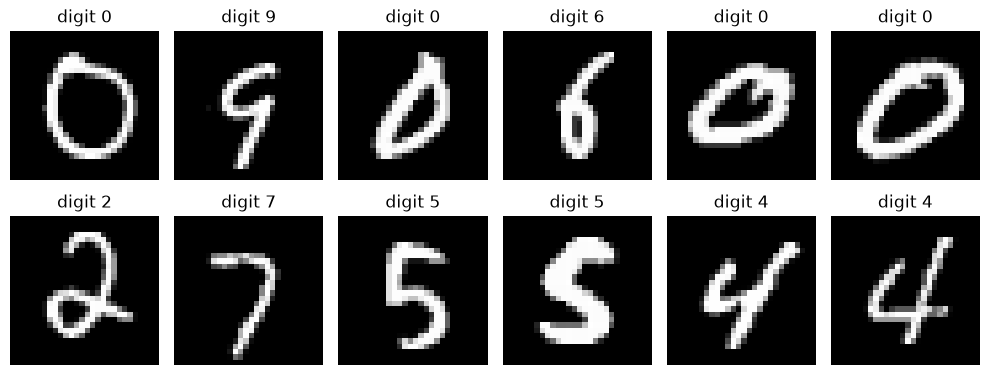

In [3]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.MNIST(root=lab_dir / 'data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root=lab_dir / 'data', train=False, download=True, transform=transform)
LOOP_DIGITS = {0, 6, 9}
NON_LOOP_DIGITS = {1, 2, 4, 5, 7}

def select_indices(targets, allowed_digits, count, seed):
    """Select reproducible examples whose labels belong to a digit set.

    Inputs: labels, allowed digit set, desired count, and random seed.
    Output: list of source-dataset positions.
    """
    choices = [i for i, label in enumerate(targets) if int(label) in allowed_digits]
    random.Random(seed).shuffle(choices)
    return choices[:count]

def display_image(image):
    """Undo normalization for display.

    Input: normalized image tensor shaped (1, 28, 28).
    Output: display tensor shaped (28, 28) in [0, 1].
    """
    return ((image * 0.5) + 0.5).clamp(0, 1).squeeze(0)

loop_preview = select_indices(train_data.targets, LOOP_DIGITS, 6, SEED)
nonloop_preview = select_indices(train_data.targets, NON_LOOP_DIGITS, 6, SEED)
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for row, indices in enumerate((loop_preview, nonloop_preview)):
    for column, index in enumerate(indices):
        image, label = train_data[index]
        axes[row, column].imshow(display_image(image), cmap='gray', vmin=0, vmax=1)
        axes[row, column].set_title(f'digit {label}')
        axes[row, column].axis('off')
axes[0, 0].set_ylabel('loop concept')
axes[1, 0].set_ylabel('comparison')
plt.tight_layout(); plt.show()

## Step 4: Learn Concept Activation Vectors

This step implements Phase 1 of the opening TCAV diagram.

In this notebook, the two groups mean:

- **Has a closed loop:** examples of `0`, `6`, and `9`. This is the concept group.
- **Does not have a closed loop:** examples of `1`, `2`, `4`, `5`, and `7`. This is the comparison group.

The word *comparison* means that the second group provides a baseline for learning what distinguishes the proposed concept. The groups are approximate: handwriting varies, so an open `6` may lack a loop and some handwritten `4`s may contain one.

### How the CAV Is Learned

1. **Convert images into internal features.** Each image passes through the trained ViT encoder. The notebook records its `[CLS]` representation, which is a vector of 64 numbers. These are the model's internal features for that image.
2. **Assign temporary concept labels.** A has-loop feature vector receives label `1`; a no-loop feature vector receives label `0`. These temporary labels train the concept detector and are separate from the ViT's original `3` and `8` output labels.
3. **Train a linear separator.** A small linear classifier learns a boundary between the two groups of 64-number vectors. Its weight vector points in the internal direction associated with the has-loop examples. After normalization, this direction is the **Concept Activation Vector**, or `CAV`.
4. **Check unseen examples.** The notebook trains the separator on 80% of the concept data and evaluates it on the remaining 20%. Held-out accuracy estimates whether the ViT features contain information that separates these two groups.
5. **Repeat five times.** Each repetition selects a different no-loop comparison sample and learns another CAV. This reveals whether the estimated concept direction is reasonably consistent or depends strongly on the selected comparison images.

In compact form:

```text
has-loop images ──► ViT's 64-number features ──┐
                                               ├─► linear separator ─► CAV
no-loop images  ──► ViT's 64-number features ──┘
```

High concept-classifier accuracy means the internal features separate the example groups. It does **not** prove that the CAV represents only closed loops: it may also capture digit identity, curvature, stroke position, or writing style. Step 4 learns the proposed concept direction; Step 5 tests whether the `3` and `8` outputs are sensitive to that direction.

In [4]:
@torch.no_grad()
def extract_features(dataset, indices, model, device, batch_size=128):
    """Extract encoder CLS features for selected dataset positions.

    Inputs: dataset, positions, trained model, inference device, and batch size.
    Output: CPU tensor shaped (number of examples, 64).
    """
    features = []
    for start in range(0, len(indices), batch_size):
        images = torch.stack([dataset[i][0] for i in indices[start:start + batch_size]]).to(device)
        features.append(model.encoder_features(images).cpu())
    return torch.cat(features)

def learn_cav(concept_features, comparison_features, seed, epochs=150):
    """Train a linear concept classifier and recover its activation-space direction.

    Inputs: concept features, comparison features, seed, and training epochs.
    Output: tuple of unit-length CAV and held-out classifier accuracy.
    """
    x = torch.cat((concept_features, comparison_features))
    y = torch.cat((torch.ones(len(concept_features)), torch.zeros(len(comparison_features))))
    generator = torch.Generator().manual_seed(seed)
    order = torch.randperm(len(x), generator=generator)
    split = int(0.8 * len(x))
    train_ids, validation_ids = order[:split], order[split:]
    mean, std = x[train_ids].mean(0), x[train_ids].std(0).clamp_min(1e-6)
    linear = nn.Linear(x.shape[1], 1)
    optimizer = torch.optim.Adam(linear.parameters(), lr=0.03)
    for _ in range(epochs):
        logits = linear((x[train_ids] - mean) / std).squeeze(1)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y[train_ids])
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    with torch.no_grad():
        predictions = (linear((x[validation_ids] - mean) / std).squeeze(1) > 0).float()
        accuracy = float((predictions == y[validation_ids]).float().mean())
        cav = (linear.weight.squeeze(0) / std).detach()
        cav = cav / cav.norm()
    return cav, accuracy

concept_indices = select_indices(train_data.targets, LOOP_DIGITS, 300, SEED + 10)
concept_features = extract_features(train_data, concept_indices, model, device)
cavs, concept_accuracies = [], []
for repetition in range(5):
    comparison_indices = select_indices(train_data.targets, NON_LOOP_DIGITS, 300, SEED + 100 + repetition)
    comparison_features = extract_features(train_data, comparison_indices, model, device)
    cav, accuracy = learn_cav(concept_features, comparison_features, SEED + repetition)
    cavs.append(cav); concept_accuracies.append(accuracy)
    print(f'Repetition {repetition + 1}: held-out concept-classifier accuracy={accuracy:.1%}')

Repetition 1: held-out concept-classifier accuracy=79.2%


Repetition 2: held-out concept-classifier accuracy=80.8%


Repetition 3: held-out concept-classifier accuracy=79.2%
Repetition 4: held-out concept-classifier accuracy=70.0%


Repetition 5: held-out concept-classifier accuracy=76.7%


## Step 5: Calculate TCAV Scores for `3` and `8`

For each target image, calculate the gradient of its **class margin** with respect to its internal `[CLS]` features. For this binary model, the margin is the target logit minus the other class's logit, so it measures evidence favoring one class over its alternative. The directional derivative is the dot product between that gradient and the CAV. The TCAV score is the fraction of target images with a positive derivative. A score above `0.5` means the class margin is positively sensitive to the learned concept direction for a majority of examples; it is not a probability or effect size.

In [5]:
def class_features(dataset, digit, count, model, device, seed):
    """Extract encoder features for one target digit.

    Inputs: dataset, digit label, count, model, device, and seed.
    Output: feature tensor shaped (count, 64).
    """
    indices = select_indices(dataset.targets, {digit}, count, seed)
    return extract_features(dataset, indices, model, device)

def tcav_score(model, features, class_index, cav, device):
    """Calculate the fraction of positive concept directional derivatives for a class margin.

    Inputs: model, encoder features, output class index, CAV, and device.
    Output: TCAV score between 0 and 1.
    """
    features = features.to(device).detach().requires_grad_(True)
    logits = model.logits_from_features(features)
    other_class = 1 - class_index
    class_margin = logits[:, class_index] - logits[:, other_class]
    gradients = torch.autograd.grad(class_margin.sum(), features)[0]
    directional_derivatives = gradients @ cav.to(device)
    return float((directional_derivatives > 0).float().mean())

three_features = class_features(test_data, 3, 200, model, device, SEED + 201)
eight_features = class_features(test_data, 8, 200, model, device, SEED + 202)
scores = {'3': [], '8': []}
for cav in cavs:
    scores['3'].append(tcav_score(model, three_features, 0, cav, device))
    scores['8'].append(tcav_score(model, eight_features, 1, cav, device))
for label in ('3', '8'):
    values = torch.tensor(scores[label])
    print(f'Class {label}: scores={scores[label]}, mean={values.mean():.3f}, standard deviation={values.std():.3f}')

Class 3: scores=[0.054999999701976776, 0.0, 0.03999999910593033, 0.0, 0.009999999776482582], mean=0.021, standard deviation=0.025
Class 8: scores=[0.03999999910593033, 0.675000011920929, 0.9900000095367432, 1.0, 0.33500000834465027], mean=0.608, standard deviation=0.419


## Step 6: Visualize and Interpret the Scores

Dots show the five repeated CAV estimates. Bars show their means, and error bars show one standard deviation. The dashed `0.5` line is a descriptive majority reference—not a statistical significance threshold.

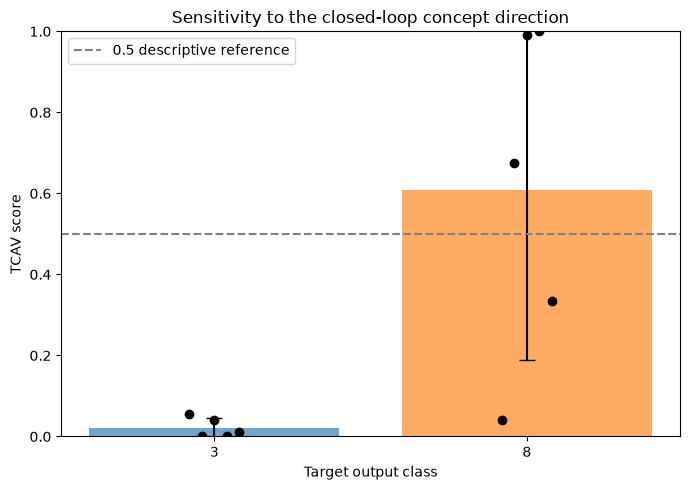

In [6]:
labels = ['3', '8']
means = [torch.tensor(scores[label]).mean().item() for label in labels]
standard_deviations = [torch.tensor(scores[label]).std().item() for label in labels]
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(labels, means, yerr=standard_deviations, capsize=6, color=['tab:blue', 'tab:orange'], alpha=0.65)
for position, label in enumerate(labels):
    jitter = torch.linspace(-0.08, 0.08, len(scores[label]))
    ax.scatter(position + jitter.numpy(), scores[label], color='black', zorder=3)
ax.axhline(0.5, color='gray', linestyle='--', label='0.5 descriptive reference')
ax.set(ylim=(0, 1), ylabel='TCAV score', xlabel='Target output class', title='Sensitivity to the closed-loop concept direction')
ax.legend(); plt.tight_layout(); plt.show()

## Interpretation and Limits

TCAV differs from patch occlusion. Occlusion explains sensitivity to locations in one image; TCAV tests sensitivity to a user-defined concept direction across many images. A higher score for `8` would be plausible because handwritten eights often contain loop structure, but it would not prove that the model recognizes loops in a human-like way. The concept examples differ in digit identity, stroke placement, and writing style, so the CAV may capture more than closed loops.

This teaching notebook reports repeated estimates and variability but does not claim statistical significance. A research-grade TCAV study should use multiple carefully curated concept and random sets, prespecified layers and hypotheses, statistical testing, and robustness checks.

## Reflection

1. How does a CAV turn example images into a direction in activation space?
2. Why are digits `3` and `8` excluded from concept-classifier training?
3. What does a TCAV score of `0.80` mean—and what does it not mean?
4. Why can high concept-classifier accuracy still reflect a confound?
5. How does TCAV answer a different question from patch occlusion?
6. What additional checks would be required before making a forensic claim?

Method reference: Been Kim et al., [*Interpretability Beyond Feature Attribution: Quantitative Testing with Concept Activation Vectors*](https://proceedings.mlr.press/v80/kim18d.html), ICML 2018.